# Hull-White Interest Rate Path Visualization

This notebook demonstrates the Hull-White model implementation and visualizes simulated interest rate paths.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import sys
sys.path.append('..')

from src.ls_pricing.core.curves import YieldCurve
from src.ls_pricing.core.hull_white import HullWhiteModel
from src.ls_pricing.engine.monte_carlo import MonteCarloEngine

# Set up plotting style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 8)

## 1. Load Market Data and Create Yield Curve

In [13]:
# Load treasury curve data with encoding handling
treasury_data = pd.read_csv('../data/active_treasury_curve.csv', encoding='latin-1')
print("Treasury Curve Data:")
print(treasury_data.head(15))

# Parse tenor strings to years
def tenor_to_years(tenor_str):
    if 'M' in tenor_str and 'Y' not in tenor_str:
        # Handle months
        months = int(tenor_str.replace('M', ''))
        return months / 12.0
    elif 'W' in tenor_str:
        # Handle weeks
        weeks = int(tenor_str.replace('W', ''))
        return weeks / 52.0
    elif 'Y' in tenor_str:
        # Handle years
        return float(tenor_str.replace('Y', ''))
    else:
        return None

# Extract and convert data
treasury_data['TenorYears'] = treasury_data['Tenor'].apply(tenor_to_years)
treasury_data['YieldDecimal'] = treasury_data['Yield'] / 100.0

# Filter out any rows with invalid tenor conversions
valid_data = treasury_data.dropna(subset=['TenorYears'])

print("\nProcessed data:")
print(valid_data[['Tenor', 'TenorYears', 'Yield', 'YieldDecimal']].head(10))

Treasury Curve Data:
   Tenor              CUSIP           Description     Price   Yield Source  \
0     1M  912797PJ@BGN Govt     B 0 05/20/25 Govt    4.2350  4.3085    BGN   
1     6W  912797NN@BGN Govt     B 0 05/29/25 Govt    4.2213  4.2990    BGN   
2     2M  912797PS@BGN Govt     B 0 06/17/25 Govt    4.2088  4.2958    BGN   
3     3M  912797PE@BGN Govt     B 0 07/17/25 Govt    4.2162  4.3188    BGN   
4     4M  912797QK@BGN Govt     B 0 08/19/25 Govt    4.2188  4.3378    BGN   
5     6M  912797QF@BGN Govt     B 0 10/16/25 Govt    4.0588  4.1994    BGN   
6     1Y  912797QD@BGN Govt     B 0 04/16/26 Govt    3.8100  3.9769    BGN   
7     2Y  91282CMV@BGN Govt  T 3 ? 03/31/27  Govt  100.1367  3.8003    BGN   
8     3Y  91282CMW@BGN Govt  T 3 ¾ 04/15/28  Govt   99.8633  3.7987    BGN   
9     5Y  91282CMU@BGN Govt     T 4 03/31/30 Govt  100.2695  3.9390    BGN   
10    7Y  91282CMT@BGN Govt  T 4 ? 03/31/32  Govt  100.0156  4.1220    BGN   
11   10Y  91282CMM@BGN Govt  T 4 ? 02/15/35

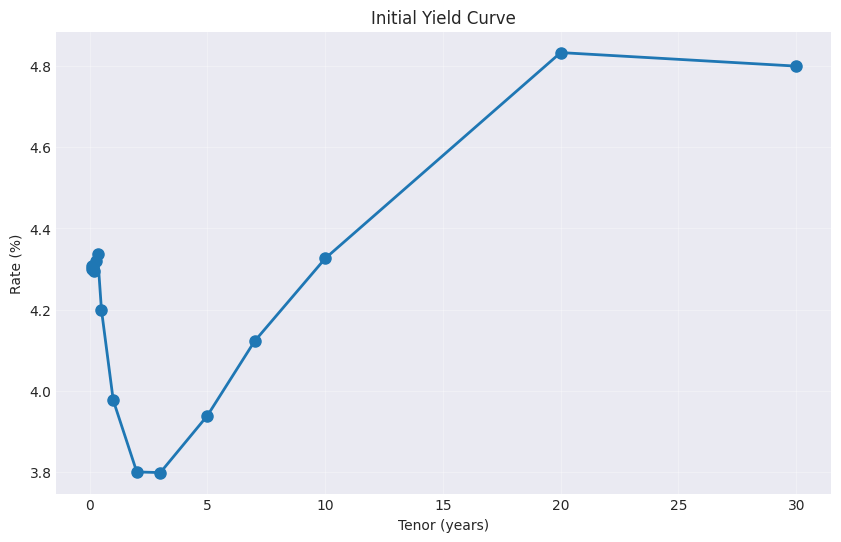

Yield curve created with 14 data points
Tenor range: 0.08 to 30.00 years


In [14]:
# Create yield curve from actual market data
# Sort data by tenor for proper interpolation
valid_data_sorted = valid_data.sort_values('TenorYears')

# Extract tenors and rates from the CSV data
tenors = valid_data_sorted['TenorYears'].values
rates = valid_data_sorted['YieldDecimal'].values

# For demo purposes, if we don't have enough data points, use some example data
if len(tenors) < 5:
    print("Using example data due to insufficient market data points")
    tenors = np.array([0.25, 0.5, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0, 20.0, 30.0])
    rates = np.array([0.0425, 0.0415, 0.0395, 0.0380, 0.0379, 0.0393, 0.0412, 0.0432, 0.0483, 0.0479])

curve_date = datetime(2025, 4, 20)
yield_curve = YieldCurve(tenors, rates, curve_date)

# Plot the yield curve
plt.figure(figsize=(10, 6))
plt.plot(tenors, rates * 100, 'o-', linewidth=2, markersize=8)
plt.xlabel('Tenor (years)')
plt.ylabel('Rate (%)')
plt.title('Initial Yield Curve')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Yield curve created with {len(tenors)} data points")
print(f"Tenor range: {tenors[0]:.2f} to {tenors[-1]:.2f} years")

## 2. Initialize Hull-White Model and Monte Carlo Engine

In [15]:
# Hull-White parameters
a = 0.05  # Mean reversion speed
sigma = 0.01  # Volatility

# Create Hull-White model
hw_model = HullWhiteModel(a=a, sigma=sigma, yield_curve=yield_curve)

# Create Monte Carlo engine
mc_engine = MonteCarloEngine(
    model=hw_model,
    n_paths=1000,
    n_steps=252*5  # Steps for the simulation (will be spread over T years)
)

print(f"Hull-White Model Parameters:")
print(f"  Mean reversion (a): {a}")
print(f"  Volatility (sigma): {sigma}")
print(f"\nMonte Carlo Engine:")
print(f"  Number of paths: {mc_engine.n_paths}")
print(f"  Number of time steps: {mc_engine.n_steps}")

Hull-White Model Parameters:
  Mean reversion (a): 0.05
  Volatility (sigma): 0.01

Monte Carlo Engine:
  Number of paths: 1000
  Number of time steps: 1260


## 3. Generate Interest Rate Paths

In [16]:
# Generate paths for different time horizons
T = 5.0  # 5 year simulation
paths = mc_engine.generate_paths(T=T, seed=42)

# Extract data
rates = paths['rates']
times = paths['times']
discount_factors = paths['discount_factors']

print(f"Generated {rates.shape[0]} paths over {rates.shape[1]} time steps")
print(f"Time horizon: {T} years")
print(f"Time step size: {T/mc_engine.n_steps:.4f} years ({T/mc_engine.n_steps * 252:.1f} trading days)")
print(f"This gives us {mc_engine.n_steps/T:.1f} steps per year")

Generated 1000 paths over 1261 time steps
Time horizon: 5.0 years
Time step size: 0.0040 years (1.0 trading days)
This gives us 252.0 steps per year


## 4. Visualize Interest Rate Paths

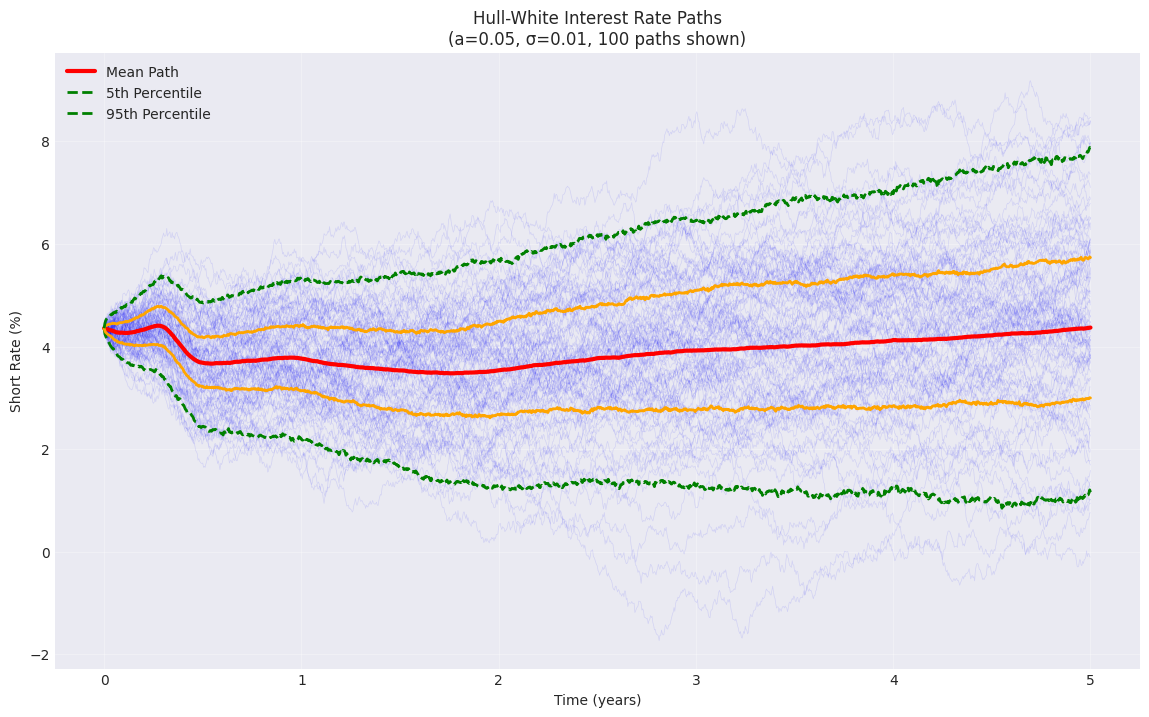

In [17]:
# Plot sample paths
n_display = 100  # Number of paths to display

plt.figure(figsize=(14, 8))

# Plot individual paths
for i in range(n_display):
    plt.plot(times, rates[i, :] * 100, alpha=0.1, color='blue', linewidth=0.5)

# Plot mean path
mean_path = np.mean(rates, axis=0) * 100
plt.plot(times, mean_path, 'r-', linewidth=3, label='Mean Path')

# Plot percentiles
percentiles = [5, 25, 75, 95]
colors = ['green', 'orange', 'orange', 'green']
styles = ['--', '-', '-', '--']

for p, color, style in zip(percentiles, colors, styles):
    path_p = np.percentile(rates, p, axis=0) * 100
    plt.plot(times, path_p, color=color, linestyle=style, linewidth=2, 
             label=f'{p}th Percentile' if p in [5, 95] else None)

plt.xlabel('Time (years)')
plt.ylabel('Short Rate (%)')
plt.title(f'Hull-White Interest Rate Paths\n(a={a}, σ={sigma}, {n_display} paths shown)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 5. Path Statistics

In [18]:
# Get path statistics
stats = mc_engine.get_path_statistics(paths)

print("Path Statistics:")
print(f"  Mean terminal rate: {stats['mean_terminal_rate']*100:.3f}%")
print(f"  Std terminal rate: {stats['std_terminal_rate']*100:.3f}%")
print(f"  Terminal rate percentiles:")
print(f"    5th percentile: {stats['percentiles'][0]*100:.3f}%")
print(f"    50th percentile: {stats['percentiles'][1]*100:.3f}%")
print(f"    95th percentile: {stats['percentiles'][2]*100:.3f}%")

Path Statistics:
  Mean terminal rate: 4.369%
  Std terminal rate: 1.994%
  Terminal rate percentiles:
    5th percentile: 1.159%
    50th percentile: 4.329%
    95th percentile: 7.880%


## 6. Terminal Rate Distribution

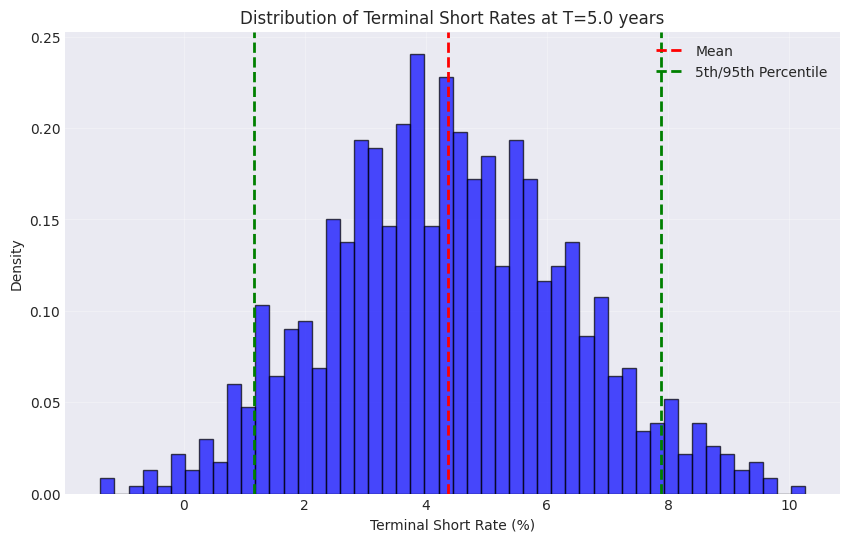

In [19]:
# Plot terminal rate distribution
terminal_rates = rates[:, -1] * 100

plt.figure(figsize=(10, 6))
plt.hist(terminal_rates, bins=50, density=True, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(stats['mean_terminal_rate']*100, color='red', linestyle='--', linewidth=2, label='Mean')
plt.axvline(stats['percentiles'][0]*100, color='green', linestyle='--', linewidth=2, label='5th/95th Percentile')
plt.axvline(stats['percentiles'][2]*100, color='green', linestyle='--', linewidth=2)

plt.xlabel('Terminal Short Rate (%)')
plt.ylabel('Density')
plt.title(f'Distribution of Terminal Short Rates at T={T} years')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 7. Mean Reversion Analysis

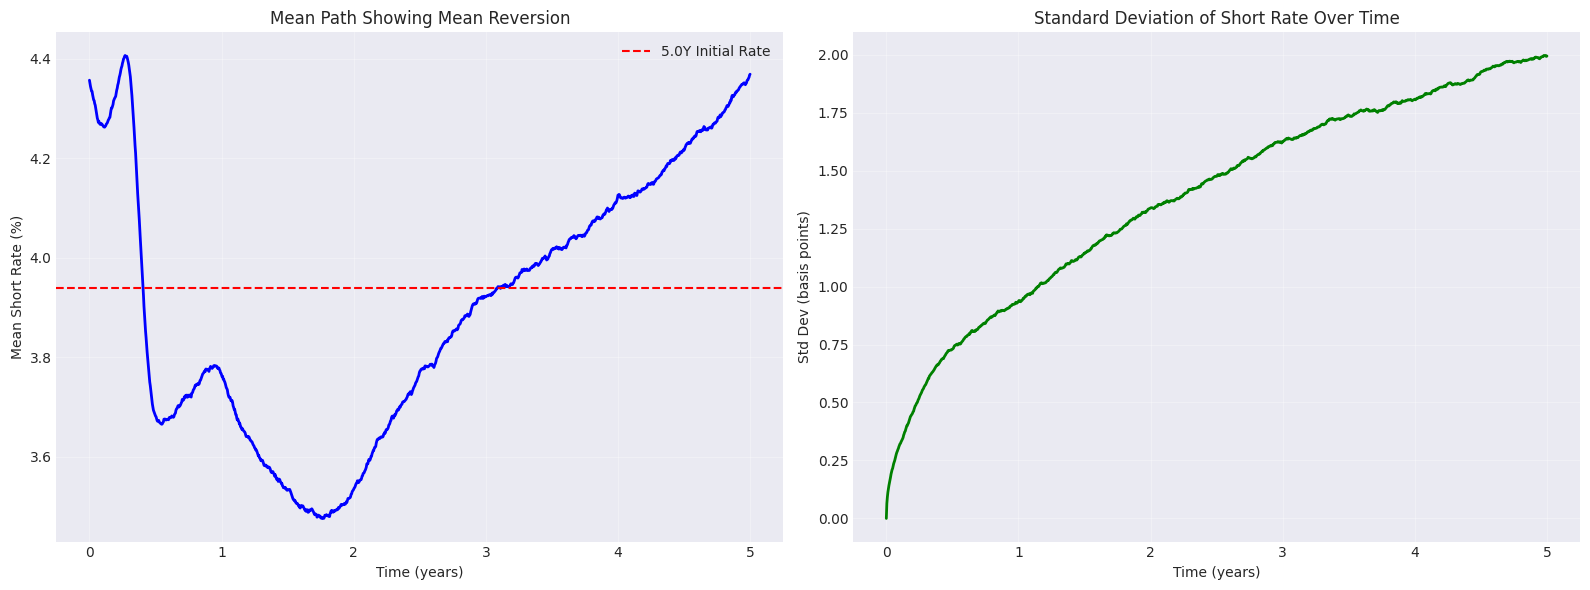

In [20]:
# Analyze mean reversion by looking at different starting rates
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Mean path over time
mean_path = stats['mean_path'] * 100
ax1.plot(times, mean_path, 'b-', linewidth=2)
ax1.axhline(y=yield_curve.get_rate(T)*100, color='r', linestyle='--', label=f'{T}Y Initial Rate')
ax1.set_xlabel('Time (years)')
ax1.set_ylabel('Mean Short Rate (%)')
ax1.set_title('Mean Path Showing Mean Reversion')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right plot: Variance over time
variance_path = np.var(rates, axis=0) * 10000  # Convert to basis points squared
ax2.plot(times, np.sqrt(variance_path), 'g-', linewidth=2)
ax2.set_xlabel('Time (years)')
ax2.set_ylabel('Std Dev (basis points)')
ax2.set_title('Standard Deviation of Short Rate Over Time')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Impact of Model Parameters

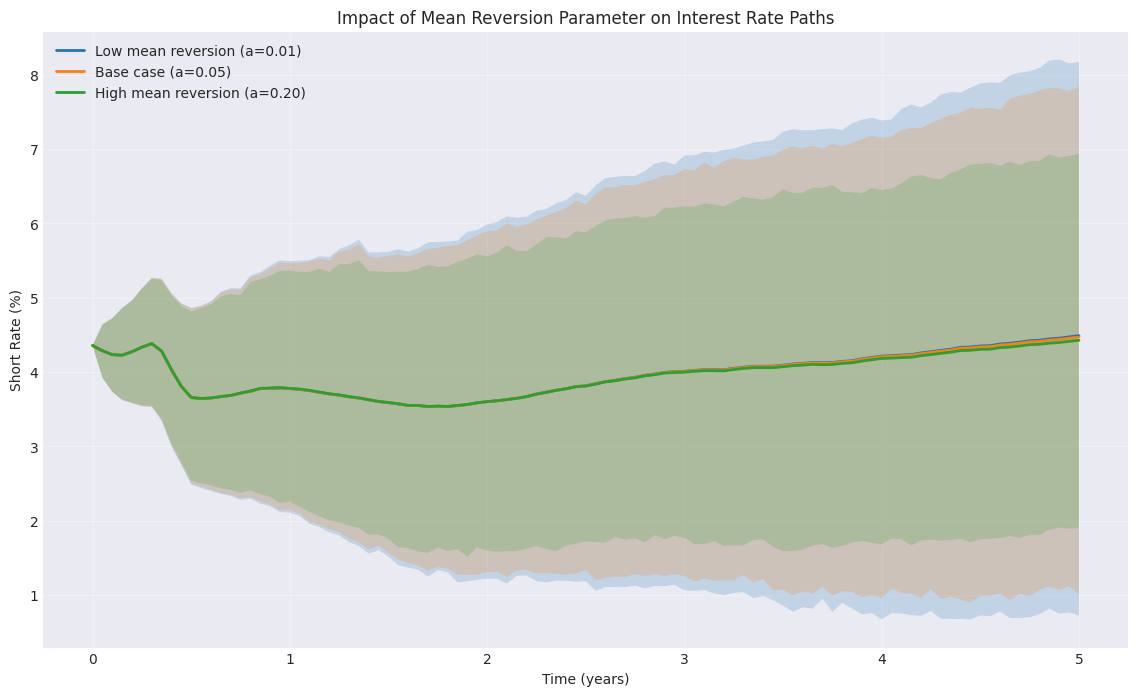

In [21]:
# Compare different parameter settings
parameters = [
    {'a': 0.01, 'sigma': 0.01, 'label': 'Low mean reversion (a=0.01)'},
    {'a': 0.05, 'sigma': 0.01, 'label': 'Base case (a=0.05)'},
    {'a': 0.20, 'sigma': 0.01, 'label': 'High mean reversion (a=0.20)'},
]

plt.figure(figsize=(14, 8))

for params in parameters:
    # Create model with different parameters
    hw_temp = HullWhiteModel(a=params['a'], sigma=params['sigma'], yield_curve=yield_curve)
    mc_temp = MonteCarloEngine(model=hw_temp, n_paths=1000, n_steps=100)
    
    # Generate paths
    paths_temp = mc_temp.generate_paths(T=T, seed=42)
    
    # Plot mean and percentiles
    mean_temp = np.mean(paths_temp['rates'], axis=0) * 100
    p5_temp = np.percentile(paths_temp['rates'], 5, axis=0) * 100
    p95_temp = np.percentile(paths_temp['rates'], 95, axis=0) * 100
    
    plt.plot(paths_temp['times'], mean_temp, linewidth=2, label=params['label'])
    plt.fill_between(paths_temp['times'], p5_temp, p95_temp, alpha=0.2)

plt.xlabel('Time (years)')
plt.ylabel('Short Rate (%)')
plt.title('Impact of Mean Reversion Parameter on Interest Rate Paths')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 9. Zero Bond Prices Along Paths

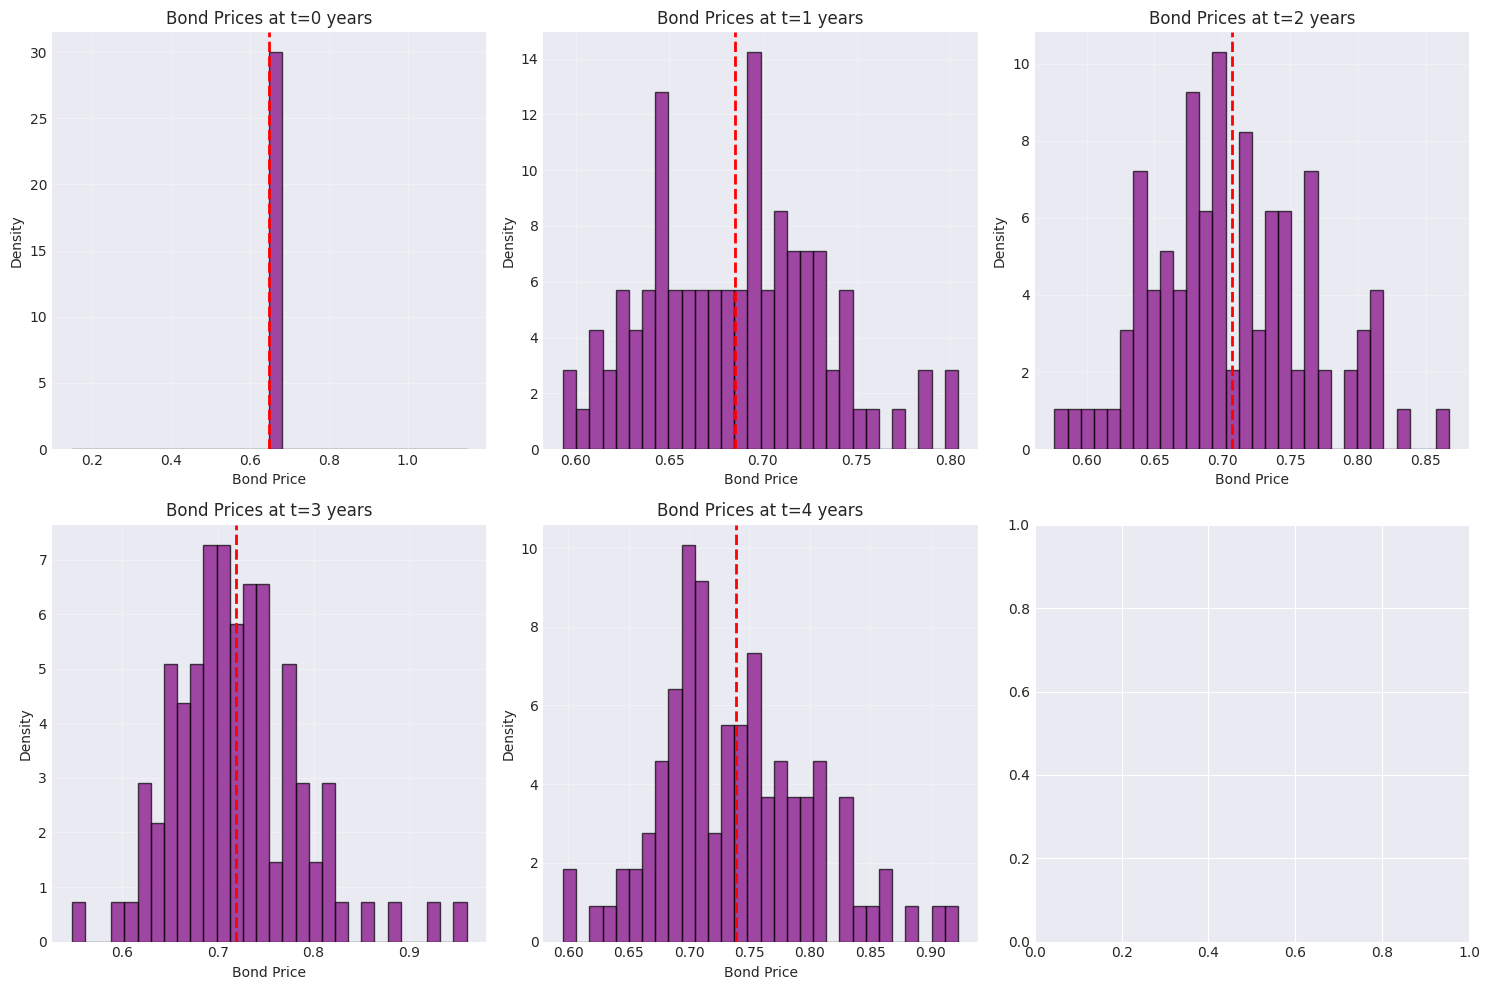

In [22]:
# Calculate zero bond prices for a 10-year bond at different points along the paths
bond_maturity = 10.0
evaluation_times = [0, 1, 2, 3, 4, 5]
bond_prices = {}

for eval_time in evaluation_times:
    if eval_time < T:
        time_idx = int(eval_time * mc_engine.n_steps / T)
        prices = []
        
        # Calculate bond price for each path at this time
        for i in range(min(100, rates.shape[0])):  # Use first 100 paths for speed
            price = hw_model.zero_bond_price(
                t=eval_time,
                T=bond_maturity,
                r_t=rates[i, time_idx]
            )
            prices.append(price)
        
        bond_prices[eval_time] = np.array(prices)

# Plot bond price distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (t, prices) in enumerate(bond_prices.items()):
    axes[i].hist(prices, bins=30, density=True, alpha=0.7, color='purple', edgecolor='black')
    axes[i].set_title(f'Bond Prices at t={t} years')
    axes[i].set_xlabel('Bond Price')
    axes[i].set_ylabel('Density')
    axes[i].axvline(np.mean(prices), color='red', linestyle='--', linewidth=2)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

This notebook demonstrates:
1. How to set up the Hull-White model with a yield curve
2. Monte Carlo simulation of interest rate paths
3. Visualization of paths and their statistics
4. Mean reversion behavior
5. Impact of model parameters
6. Zero bond pricing along the paths

The Hull-White model successfully captures the mean-reverting nature of interest rates and provides a realistic framework for pricing interest rate derivatives.